# Notebook purpose

This notebook preserves the exploratory workflow from `agrupamento_deputados.ipynb`.

Purpose: Explore the deputy-level semantic map built from pooled speech embeddings.

Related production code/script: `src/embeddings/aggregation.py`, `src/clustering/deputies.py`, `scripts/run_clustering.py --stage deputy`.


In [ ]:
import pandas as pd
import numpy as np
from tqdm.auto import tqdm
import os

# Bibliotecas para a mágica acontecer
import umap.umap_ as umap
import matplotlib.pyplot as plt
import seaborn as sns

import re

In [12]:
party_colors = {
    # Paleta de alto contraste para máxima diferenciação visual.
    "PT": "#E6194B",    # Vermelho
    "MDB": "#046600",    # Azul
    "PSDB": "#3cb44b",  # Verde
    "PL": "#ffe119",    # Amarelo
    "DEM": "#4363d8",    # Magenta
    "UNIÃO": "#4363d8",  # Laranja
    "PP": "#ff7b00",    # Roxo
    "PSB": "#e01f3f",    # Laranja
    "PCdoB": "#3A0000",  # Marrom (Vinho)
    "PDT": "#c42895",    # Ciano
    "PSOL": "#490364",   # Marrom (Sépia)
}

In [ ]:
print("Iniciando a análise do 'DNA dos Partidos'...")

# --- Passo 1: Carregar e Preparar os Dados ---
print("Carregando dados pré-processados...")
try:
    df = pd.read_csv('data/discursos_camara_2003_2025_limpos.csv')
    df = df[df['partido'].isin(party_colors.keys())]  # Filtra apenas partidos conhecidos
    embeddings = np.load('data/discursos_camara_2003_2025_limpos_Linq_embeddings_norm.npy')
    assert len(df) == len(embeddings), "O número de linhas no CSV e nos embeddings não bate!"
except FileNotFoundError:
    print("Erro: Arquivos 'discursos_limpos.csv' ou 'embeddings_discursos.npy' não encontrados.")
    exit()

# --- Passo 2: Agregar Embeddings por PARTIDO e Ano ---
print("Agregando embeddings por deputado e por ano...")
embedding_list = [emb for emb in embeddings]
df['embedding'] = embedding_list


Embeddings agregados para 1881 deputados únicos.
Reduzindo a dimensionalidade com UMAP...


/home/flaviossf/defaultenv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/flaviossf/defaultenv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Preparando dados para a visualização...
Gerando o gráfico estático...

✔️ Gráfico estático salvo como 'mapa_politico_estatico.png'


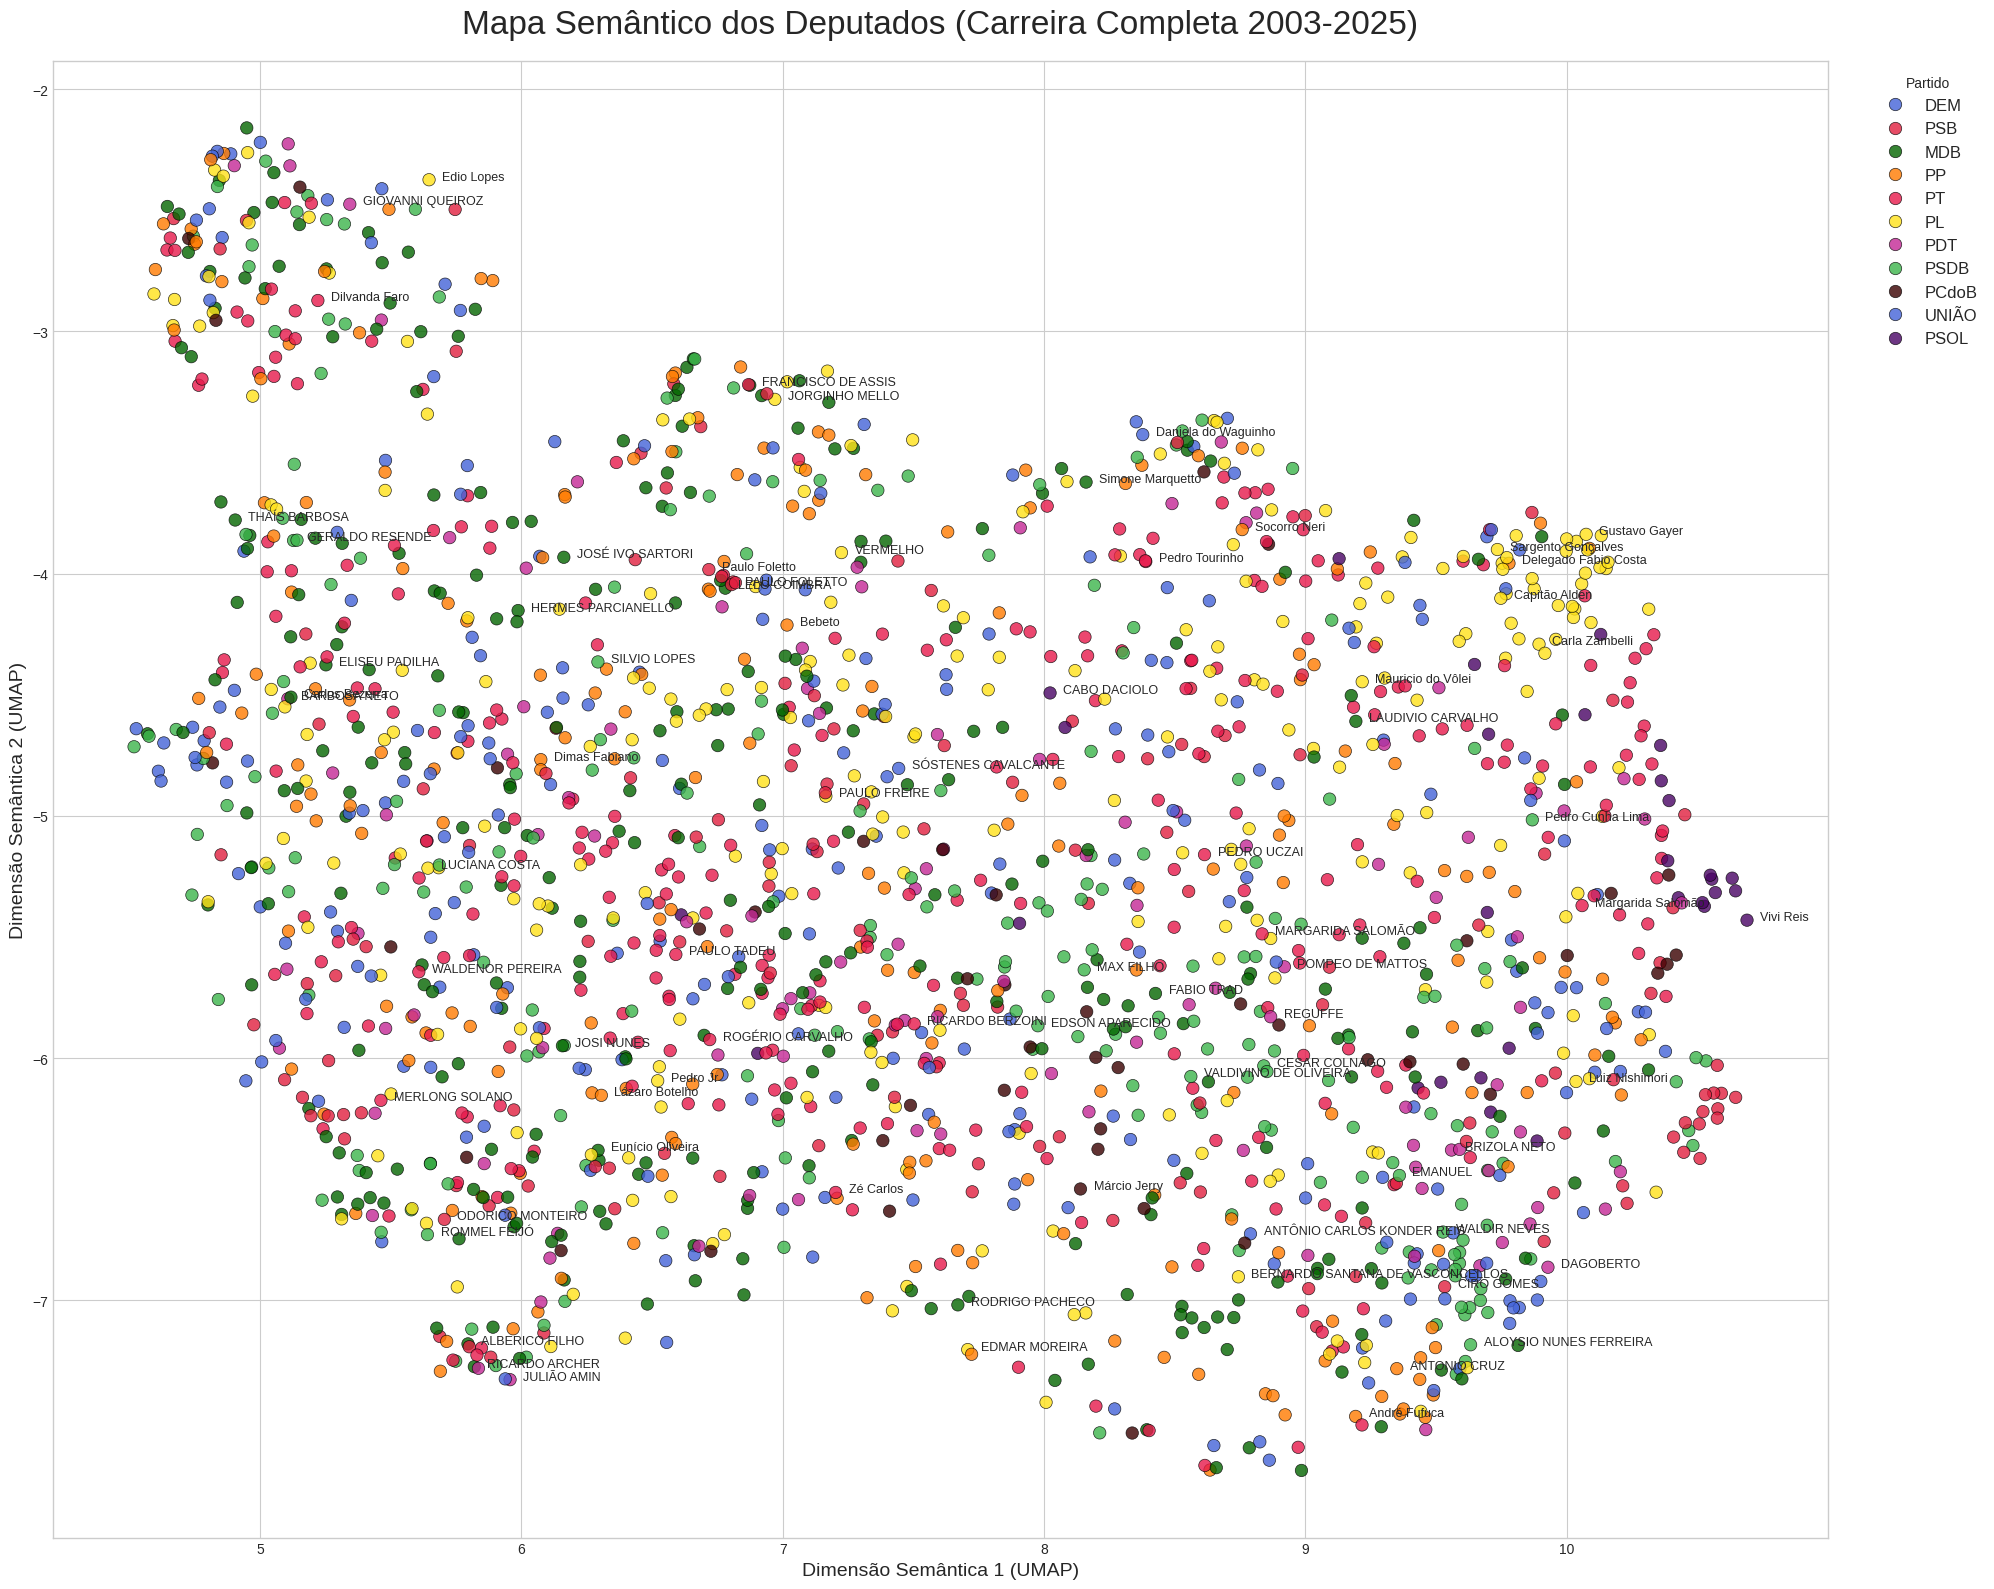

In [14]:
# A MUDANÇA PRINCIPAL ESTÁ AQUI: agrupamos APENAS por 'nome'
df_filtrado = df[df['partido'].isin(party_colors.keys())].copy()
deputy_embeddings_df = df_filtrado.groupby('nome')['embedding'].apply(lambda x: np.mean(x.tolist(), axis=0))
deputy_embeddings_df = pd.DataFrame(deputy_embeddings_df.tolist(), index=deputy_embeddings_df.index)

print(f"Embeddings agregados para {len(deputy_embeddings_df)} deputados únicos.")


# --- Passo 3: Reduzir a Dimensionalidade com UMAP ---
print("Reduzindo a dimensionalidade com UMAP...")
reducer = umap.UMAP(n_neighbors=40, min_dist=0.1, n_components=2, random_state=42)
embedding_2d = reducer.fit_transform(deputy_embeddings_df)


# --- Passo 4: Preparar DataFrame Final para Plotagem ---
print("Preparando dados para a visualização...")
df_plot = pd.DataFrame(embedding_2d, columns=['x', 'y'])
df_plot['nome'] = deputy_embeddings_df.index

# Mapeia o partido de cada deputado. Usamos 'last' para pegar o partido mais recente registrado.
party_map = df_filtrado.drop_duplicates('nome', keep='last').set_index('nome')['partido']
df_plot['partido'] = df_plot['nome'].map(party_map)

# Filtra para partidos com um número mínimo de deputados para um gráfico mais limpo

df_plot_filtrado = df_plot

# --- Passo 5: Visualização do Mapa Estático ---
print("Gerando o gráfico estático...")
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(20, 16))

# Não há mais o loop de trajetória, plotamos todos os pontos de uma vez
sns.scatterplot(
    data=df_plot_filtrado, 
    x='x', 
    y='y', 
    hue='partido',          # Colore os pontos pelo partido
    palette=party_colors,   # Usa nossa paleta de cores personalizada
    s=80,                   # Tamanho dos pontos
    alpha=0.8,
    edgecolor='black',
    linewidth=0.5,
    ax=ax
)

# Adiciona os nomes de um subconjunto de deputados para não poluir o gráfico
# Você pode aumentar o 'n' se quiser mais nomes
for i, point in df_plot_filtrado.sample(n=75, random_state=42).iterrows(): 
    ax.text(point['x'] + 0.05, point['y'], str(point['nome']), fontsize=9)

# Configurações finais do gráfico
ax.set_title('Mapa Semântico dos Deputados (Carreira Completa 2003-2025)', fontsize=24, pad=20)
ax.set_xlabel('Dimensão Semântica 1 (UMAP)', fontsize=14)
ax.set_ylabel('Dimensão Semântica 2 (UMAP)', fontsize=14)
ax.legend(title='Partido', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=12)

plt.tight_layout()
output_filename = 'mapa_politico_estatico.png'
plt.savefig(output_filename, dpi=300)
print(f"\n✔️ Gráfico estático salvo como '{output_filename}'")
plt.show()